In [1]:
%load_ext autoreload
%autoreload 2
import soccer_pattern_recognition as spr

import os
import tqdm
import numpy as np
import pandas as pd

import socceraction.spadl as spadl

In [2]:
datafolder = "../data"
fifa2018h5 = os.path.join(datafolder, "spadl-fifa2018.h5")
games = pd.read_hdf(fifa2018h5, key="games")
with pd.HDFStore(fifa2018h5) as store:
    actions = []  #list of DataFrames
    for game in tqdm.tqdm(games.itertuples()):
        game_action = store[f"actions/game_{game.game_id}"]
        game_action = spadl.play_left_to_right(game_action, game.home_team_id)
        game_action["is_home"] = game_action["team_id"] == game.home_team_id
        actions.append(game_action)
    actions = pd.concat(actions)
    actions.drop("original_event_id", axis=1, inplace=True)
    actions = pd.merge(actions, spadl.config.actiontypes_df(), how="left")

64it [00:00, 198.81it/s]


In [3]:
ACTION_MAP = {#'clearance': 0,
              'corner': 1,
              'cross': 2,
              'dribble': 3,
              'freekick': 4,
              'goalkick': 5,
              'keeper_action': 6,
              'pass': 7,
              'shot': 8,
              'throw_in': 9}

ACTION_MAP = {'clearance': 0,
              'corner': 10,
              'cross': 7,
              'dribble': 3,
              'freekick': 10,
              'goalkick': 10,
              'keeper_action': 10,
              'pass': 7,
              'shot': 8,
              'throw_in': 10}

X, lenghts = spr.prepare_data(actions, ACTION_MAP)

In [4]:
emission_hyperparams = {#'clearance': [3, "k-means",2,"k-means"],
              'corner': [2, "k-means",2,"k-means"],
              'cross': [3, "k-means",2,"k-means"],
              'dribble': [3, "k-means",2,"k-means"],
              'freekick': [2, "k-means",2,"k-means"],
              'goalkick': [2, "k-means",2,"k-means"],
              'keeper_action': [2, "k-means",2,"k-means"],
              'pass': [3, "k-means",2,"k-means"],
              'shot': [2, "k-means",2,"k-means"],
              'throw_in': [2, "k-means",2,"k-means"]}

emission_hyperparams = {
        'starting' : [6 , "k-means",2,"k-means"],
        'pass': [4, "k-means",2,"k-means"],
        'dribble' : [4, "k-means",2,"k-means"],
        'shot' : [2, "k-means",1,"k-means"]
                }

models = {n_states: spr.TwoLayerHMM(emission_hyperparams, n_states)
          for n_states in range(2,4)}


In [5]:
models[2].fit(X, lenghts)

,emission_hyperparams,"{'dribble': [4, 'k-means', ...], 'pass': [4, 'k-means', ...], 'shot': [2, 'k-means', ...], 'starting': [6, 'k-means', ...]}"
,n_components,2
,ignore_actions,False
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'


In [6]:
models[3].fit(X, lenghts)

/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hierarchical/two_layer.py:449: RuntimeWarning: divide by zero encountered in log
  return logsumexp(np.log(layer1_pdf) + layer2_log_pdf, axis=1)  # (N,)


,emission_hyperparams,"{'dribble': [4, 'k-means', ...], 'pass': [4, 'k-means', ...], 'shot': [2, 'k-means', ...], 'starting': [6, 'k-means', ...]}"
,n_components,3
,ignore_actions,False
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'


In [10]:
models[3].export_model_params()

{'n_components': 3,
 'n_features': 5,
 'startprob': [0.7494619998046489, 0.250502441447347, 3.555874800411594e-05],
 'transmat': [[0.4112151210231705, 0.16113893978926902, 0.42764593918756055],
  [0.4988703767596361, 0.4985050720288228, 0.002624551211541112],
  [0.7404409300188047, 0.25941287594685103, 0.00014619403434411486]],
 'emission': {'ignore_actions': False,
  'model_actions': ['starting', 'pass', 'dribble', 'shot'],
  'hyperparams': {'starting': [6, 'k-means', 2, 'k-means'],
   'pass': [4, 'k-means', 2, 'k-means'],
   'dribble': [4, 'k-means', 2, 'k-means'],
   'shot': [2, 'k-means', 1, 'k-means']},
  'action_pi': [{'starting': 0.0449748254789744,
    'pass': 0.5960704655173703,
    'dribble': 0.35014468818869415,
    'shot': 0.008810020814957837},
   {'starting': 0.012660111689990181,
    'pass': 0.48696669974820544,
    'dribble': 0.4886091940753695,
    'shot': 0.011763994486433138},
   {'starting': 0.00013773266850836079,
    'pass': 0.25681832872235205,
    'dribble': 0.7

In [12]:
np.set_printoptions(precision=4, suppress=True)

for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    print("Start probabilities")
    print(model.startprob_)
    print("\nTransition matrix")
    print(model.transmat_)
    print(f"\n")

Model with 2 states:
Start probabilities
[0.9998 0.0002]

Transition matrix
[[0.9492 0.0508]
 [0.8562 0.1438]]


Model with 3 states:
Start probabilities
[0.7495 0.2505 0.    ]

Transition matrix
[[0.4112 0.1611 0.4276]
 [0.4989 0.4985 0.0026]
 [0.7404 0.2594 0.0001]]




In [14]:
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for action in emission_hyperparams.keys():
        for state in range(2):
            print(f"   State: {state}, {action}")
            print(model.emission.action_mom_[state][action].layer1_mixture)
            print(model.emission.action_mom_[state][action].layer2_mixtures)
    print(f"\n")

Model with 2 states:
   State: 0, starting
MixtureModel(n_components=6)
  ├─ (0) w=0.285  MultivariateGaussian(d=2, mean=[65.158  0.706], cov=[[633.818  -0.011], [-0.011  0.183]])
  ├─ (1) w=0.181  MultivariateGaussian(d=2, mean=[ 4.088 34.153], cov=[[ 3.421 -0.457], [-0.457 10.286]])
  ├─ (2) w=0.137  MultivariateGaussian(d=2, mean=[43.572 17.64 ], cov=[[403.806 -29.115], [-29.115 123.348]])
  ├─ (3) w=0.024  MultivariateGaussian(d=2, mean=[22.096 54.272], cov=[[92.119 21.92 ], [21.92 77.49]])
  ├─ (4) w=0.289  MultivariateGaussian(d=2, mean=[65.385 67.293], cov=[[705.85   -1.472], [-1.472  0.189]])
  └─ (5) w=0.083  MultivariateGaussian(d=2, mean=[54.581 50.868], cov=[[215.916   2.582], [  2.582 113.935]])
[MixtureModel(n_components=2)
  ├─ (0) w=0.600  VonMises(loc=70.5 deg, kappa=2.614)
  └─ (1) w=0.400  VonMises(loc=158.8 deg, kappa=17.247), MixtureModel(n_components=2)
  ├─ (0) w=0.299  VonMises(loc=-172.3 deg, kappa=0.342)
  └─ (1) w=0.701  VonMises(loc=-5.1 deg, kappa=1.106), M

In [15]:
for n_state, model in models.items():
    print(f"\nModel with {n_state} states:")
    df = pd.DataFrame(model.emission.action_pi_).round(4) * 100
    df.index = [f"S{i}" for i in df.index]
    print(df.to_string())


Model with 2 states:
    starting   pass  dribble  shot
S0      2.84  49.55    46.67  0.94
S1      0.02  51.30    46.81  1.87

Model with 3 states:
    starting   pass  dribble  shot
S0      4.50  59.61    35.01  0.88
S1      1.27  48.70    48.86  1.18
S2      0.01  25.68    73.31  1.00


Model with 2 states:


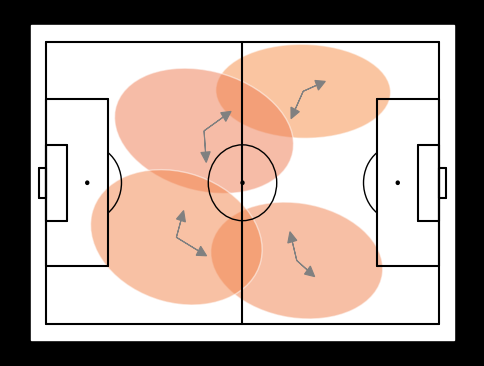

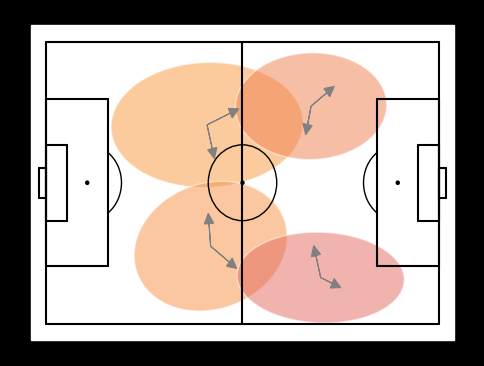

Model with 3 states:


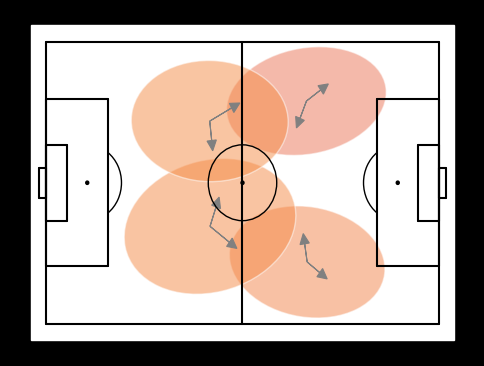

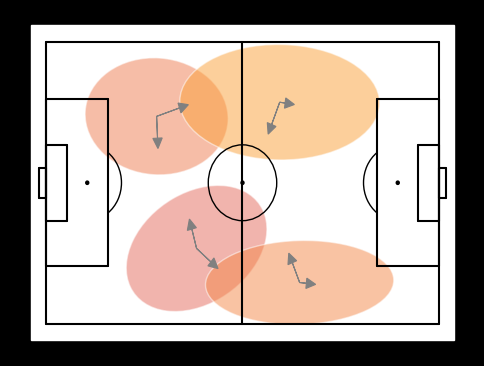

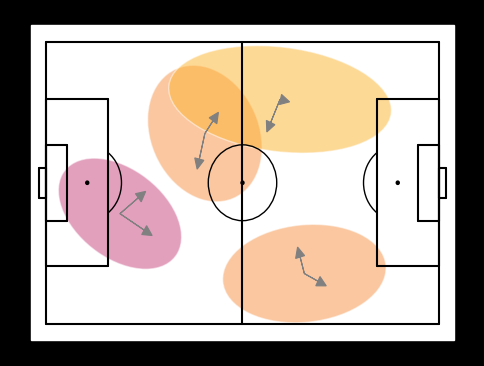

In [16]:
action_name = "pass"
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for state in range(n_state):
        model.emission.action_mom_[state][action_name].plot()

Model with 2 states:


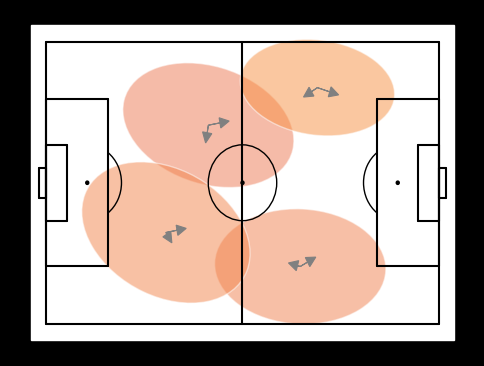

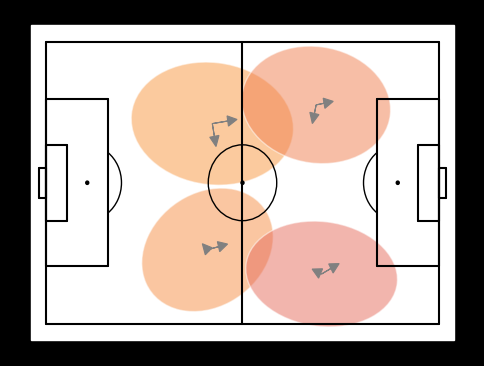

Model with 3 states:


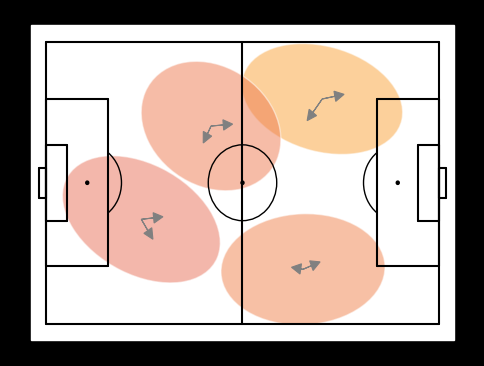

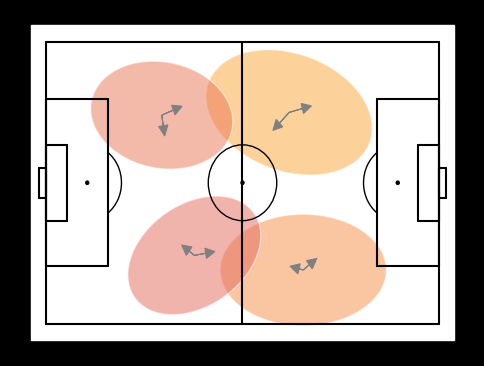

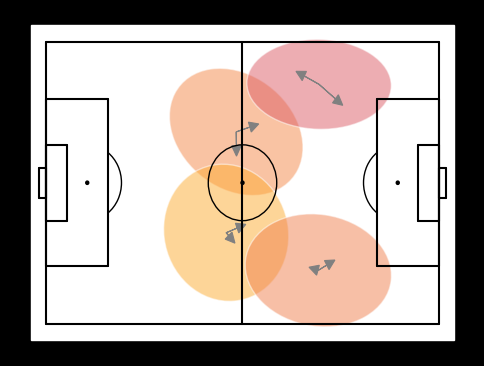

In [17]:
action_name = "dribble"
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for state in range(n_state):
        model.emission.action_mom_[state][action_name].plot()

Action: starting
Model with 2 states:


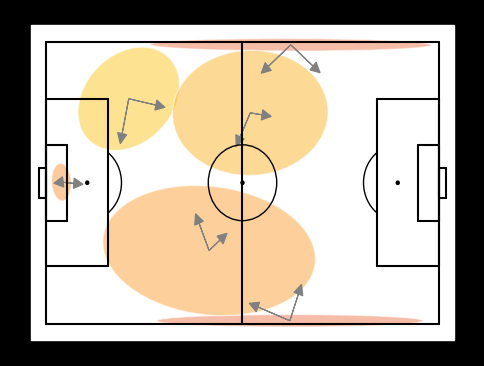

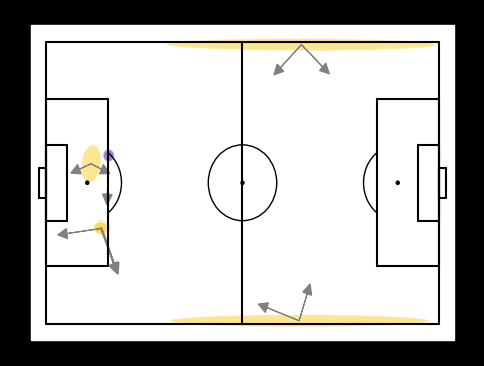

Model with 3 states:


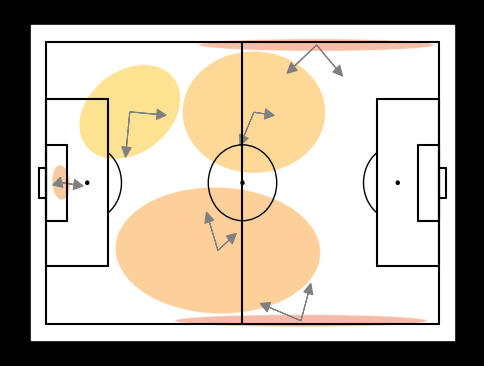

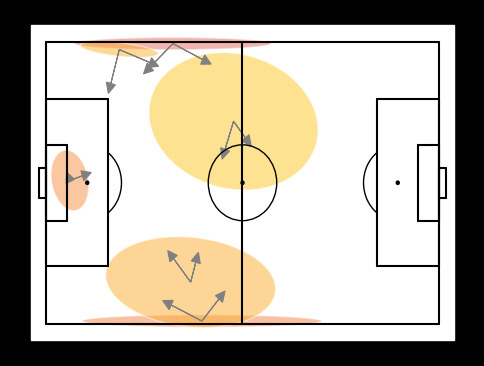

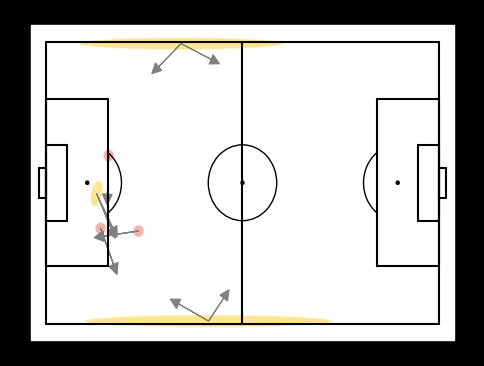

Action: pass
Model with 2 states:


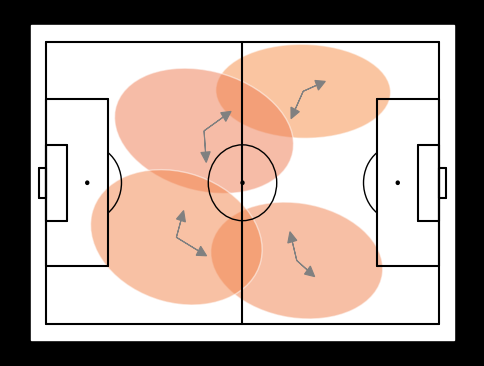

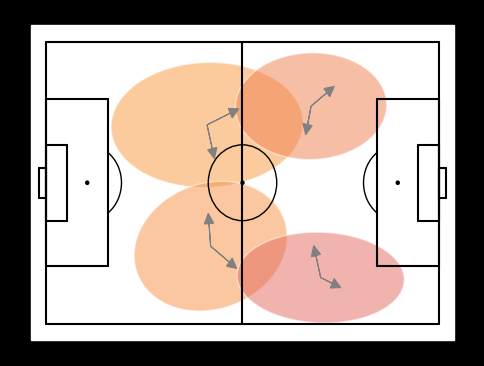

Model with 3 states:


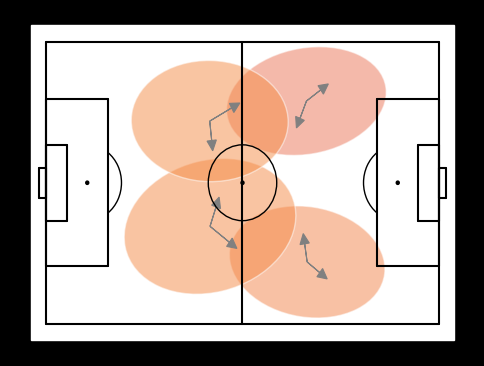

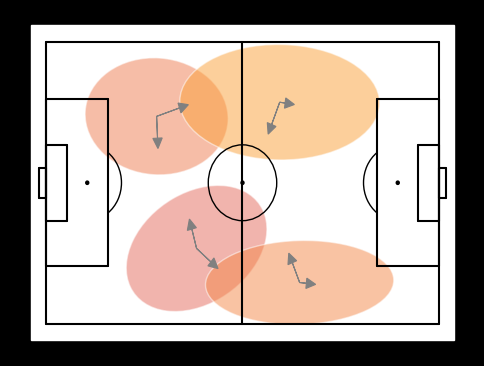

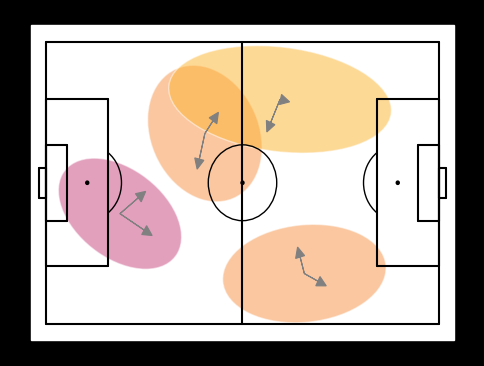

Action: dribble
Model with 2 states:


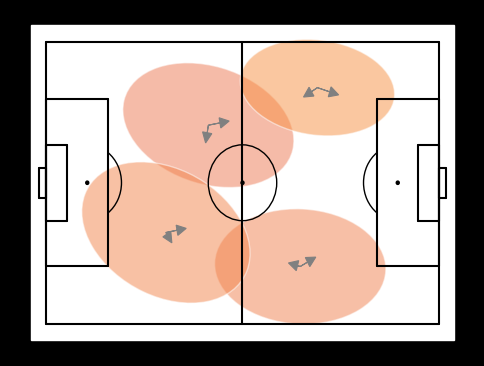

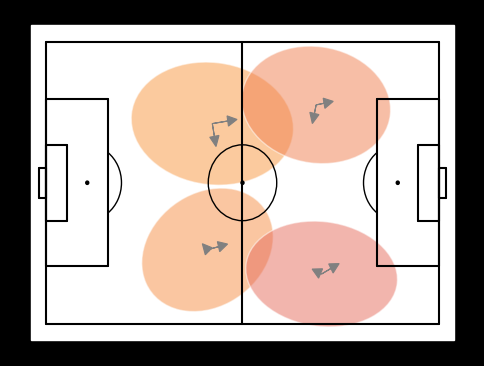

Model with 3 states:


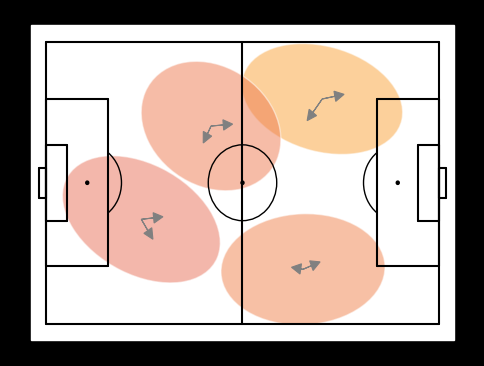

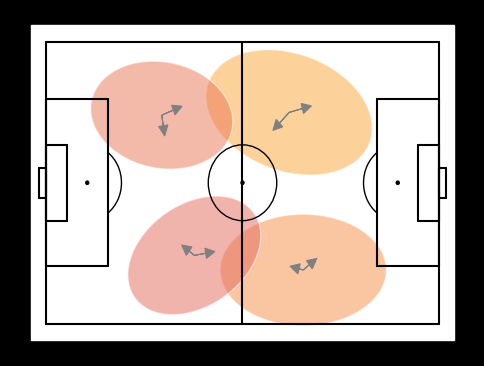

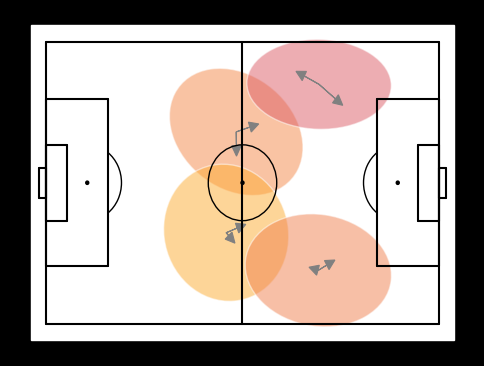

Action: shot
Model with 2 states:


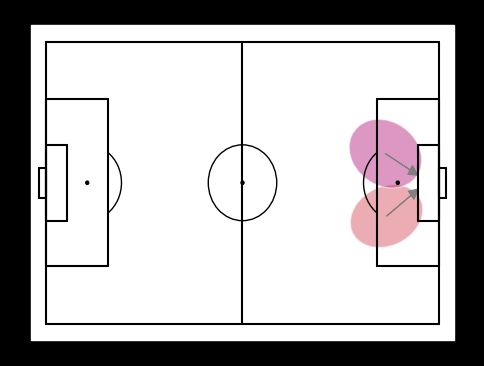

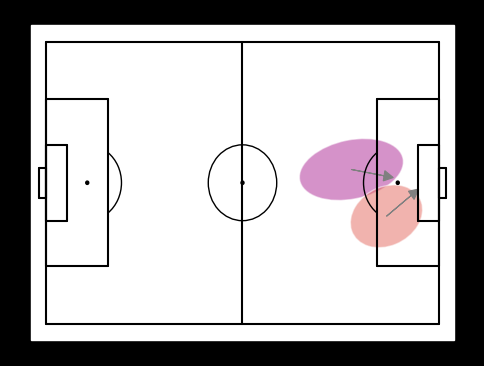

Model with 3 states:


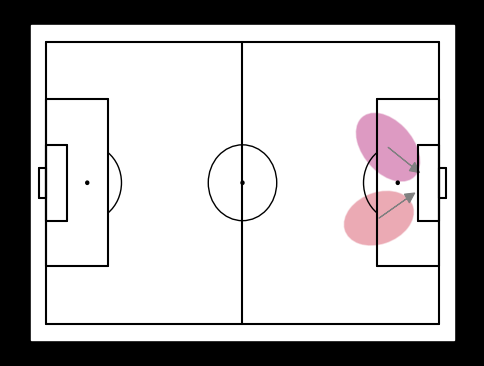

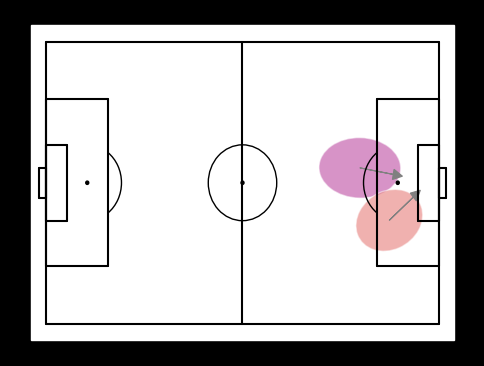

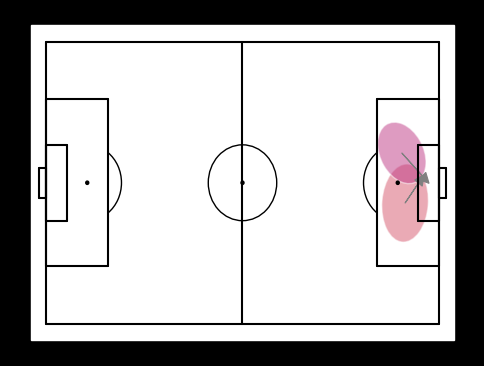

In [19]:
for action in emission_hyperparams.keys():
    print(f"Action: {action}")
    for n_state, model in models.items():
        print(f"Model with {n_state} states:")
        for state in range(n_state):
            model.emission.action_mom_[state][action].plot()